In [25]:
import random
import copy
import torch
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np

from collections import defaultdict

from causal_gym import AntMazePCH
from causal_rl.algo.imitation.imitate import *
from causal_rl.algo.imitation.finetune import *
from causal_rl.algo.imitation.gail.core_net import *
from causal_rl.algo.imitation.gail.causal_gail import *
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 150,
})

In [26]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [27]:
num_steps = 1000
hidden_dims = {'O'}

In [28]:
# for eval: corrupted W, O hidden
eval_env = AntMazePCH(env_id='antmaze-medium-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=False)

In [29]:
# load model
MODEL_PATH = '/home/et2842/causal/causalrl/models/antmaze_causal_bc.pt'
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

action_bounds = (ckpt['action_bounds_low'], ckpt['action_bounds_high'])

causal_bc_model = ContinuousPolicyNN(
    input_dim=ckpt['input_dim'],
    action_dim=ckpt['num_actions'],
    hidden_dim=ckpt['hidden_dim'],
    num_blocks=ckpt['num_blocks'],
    dropout=ckpt['dropout'],
    layernorm=ckpt['layernorm'],
    final_tanh=ckpt['final_tanh'],
    action_bounds=action_bounds,
).to(device)

causal_bc_model.load_state_dict(ckpt['state_dict'])
causal_bc_model.eval()

slots = ckpt['slots']
Z_trim = ckpt['Z_trim']
dims = ckpt['dims']
lookback = ckpt['lookback']

causal_bc_policy = shared_policy_fn_long_horizon(causal_bc_model, slots, Z_trim, continuous=True, device=device)
causal_bc_policies = make_shared_policy_dict(causal_bc_policy)

In [ ]:
num_eval_eps = 1000

causal_bc_returns = collect_imitator_trajectories(
    env=eval_env,
    policies=causal_bc_policies,
    num_episodes=num_eval_eps,
    max_steps=num_steps,
    hidden_dims=hidden_dims,
    show_progress=True
)

len(causal_bc_returns)

Starting episode 1/10...
  Episode 1 ended at step 348 (terminated: True, truncated: False).
Starting episode 2/10...
  Episode 2 ended at step 291 (terminated: True, truncated: False).
Starting episode 3/10...


  Episode 3 ended at step 292 (terminated: True, truncated: False).
Starting episode 4/10...
  Episode 4 ended at step 425 (terminated: True, truncated: False).
Starting episode 5/10...
  Episode 5 ended at step 1000 (terminated: False, truncated: True).
Starting episode 6/10...
  Episode 6 ended at step 369 (terminated: True, truncated: False).
Starting episode 7/10...
  Episode 7 ended at step 1000 (terminated: False, truncated: True).
Starting episode 8/10...
  Episode 8 ended at step 280 (terminated: True, truncated: False).
Starting episode 9/10...
  Episode 9 ended at step 1000 (terminated: False, truncated: True).
Starting episode 10/10...
  Episode 10 ended at step 298 (terminated: True, truncated: False).
Finished collecting imitator trajectories.


5303

In [31]:
causal_bc_episode_rewards = defaultdict(float)
for rec in causal_bc_returns:
    ep = rec['episode']
    causal_bc_episode_rewards[ep] += float(rec['reward'])

causal_bc_rewards = [causal_bc_episode_rewards[e] for e in range(num_eval_eps)]
sum(causal_bc_rewards) / num_eval_eps

-141.73869872164528

In [32]:
mean_reward = np.mean(causal_bc_rewards)
std_reward = np.std(causal_bc_rewards)

print(f"E[Y]          = {mean_reward:.4f}")
print(f"Std[Y]        = {std_reward:.4f}")
print(f"E[Y] ± Std[Y] = {mean_reward:.4f} ± {std_reward:.4f}")

E[Y]          = -141.7387
Std[Y]        = 108.9489
E[Y] ± Std[Y] = -141.7387 ± 108.9489


In [33]:
# success rate: % of episodes solved in under 1000 steps
ep_lengths = defaultdict(int)
for rec in causal_bc_returns:
    ep_lengths[rec['episode']] += 1

lengths = np.array([ep_lengths[e] for e in range(num_eval_eps)])
successes = lengths < num_steps
success_rate = successes.mean()
se = np.sqrt(success_rate * (1 - success_rate) / num_eval_eps)

print(f"Success rate   = {100 * success_rate:.2f}% ({successes.sum()}/{num_eval_eps} episodes)")
print(f"Std error      = {100 * se:.2f}%")

Success rate   = 70.00% (7/10 episodes)
Std error      = 14.49%


In [34]:
# successful episode lengths
success_lengths = lengths[successes]

if len(success_lengths) > 0:
    print(f"Successful episode lengths (n={len(success_lengths)}):")
    print(f"  Mean   = {np.mean(success_lengths):.2f}")
    print(f"  Std    = {np.std(success_lengths):.2f}")
    print(f"  Median = {np.median(success_lengths):.0f}")
    print(f"  Min    = {np.min(success_lengths)}")
    print(f"  Max    = {np.max(success_lengths)}")
    print(f"  25th%  = {np.percentile(success_lengths, 25):.0f}")
    print(f"  75th%  = {np.percentile(success_lengths, 75):.0f}")
else:
    print("No episodes were solved.")

Successful episode lengths (n=7):
  Mean   = 329.00
  Std    = 49.79
  Median = 298
  Min    = 280
  Max    = 425
  25th%  = 292
  75th%  = 358


In [35]:
from matplotlib.collections import LineCollection

def get_episode_xy_from_records(records, episode_id: int):
    ep = [r for r in records if r['episode'] == episode_id]
    ep = sorted(ep, key=lambda r: r['step'])
    xs, ys = [], []
    for r in ep:
        pos = r['obs']['P'][-1]
        xs.append(pos[0])
        ys.append(pos[1])
    return np.array(xs), np.array(ys)

def plot_ant_xy_trajectory(records, episode_id: int = 0, ax=None, title_prefix='AntMaze Medium'):
    xs, ys = get_episode_xy_from_records(records, episode_id)
    T = len(xs)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    t_norm = np.linspace(0, 1, T - 1)
    lc = LineCollection(segments, cmap='twilight', norm=plt.Normalize(0, 1))
    lc.set_array(t_norm)
    lc.set_linewidth(2.0)
    ax.add_collection(lc)

    ax.scatter(xs[0], ys[0], s=90, c="#2c30a0", marker='o', edgecolors='black', linewidths=0.8, zorder=5, label='Start')
    ax.scatter(xs[-1], ys[-1], s=90, c='#d62728', marker='X', edgecolors='black', linewidths=0.8, zorder=5, label='End')

    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Time (normalized)')

    ax.set_aspect('equal', 'box')
    ax.set_xlabel('$x$ position')
    ax.set_ylabel('$y$ position')
    ax.set_title(f'{title_prefix} ({T} steps)', fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', framealpha=0.9, edgecolor='gray')
    return fig, ax

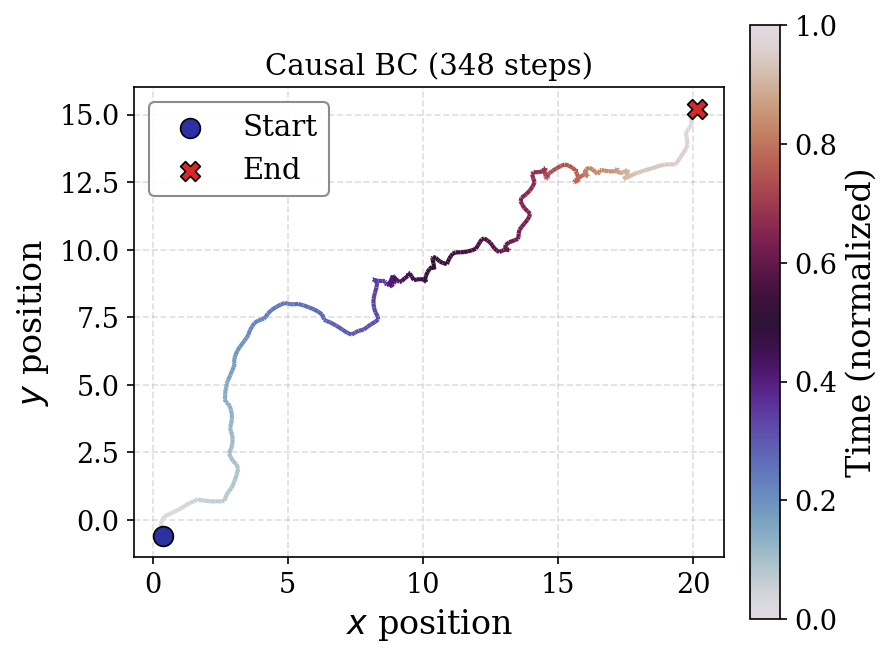

In [36]:
# trajectory heatmaps for 1 random episode
rng = np.random.default_rng(42)
sample_eps = rng.choice(num_eval_eps, size=1, replace=False)

fig, axes = plt.subplots(1, 1, figsize=(6, 6))
for ax, ep_id in zip([axes], sample_eps):
    plot_ant_xy_trajectory(causal_bc_returns, episode_id=int(ep_id), ax=ax,
                           title_prefix='Causal BC')
plt.tight_layout()
fig.savefig('/home/et2842/causal/causalrl/examples/experiments/plots/antmaze-medium/antmed_cbc_traj.pdf', dpi=300, bbox_inches='tight')
plt.show()